## 1. Setup e Imports

In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

# Configuración de reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f' Usando device: {device}')

 Usando device: cpu


## 2. Configuración del SAE

**Nota:** Las activaciones ya fueron extraídas previamente con `run_extraction.py`.  
Aquí solo especificamos qué archivo cargar y los hiperparámetros del SAE.

In [33]:
# Configuración del SAE
CONFIG = {
    # Arquitectura
    'input_dim': 512,           # Dimensión de activaciones del GPT
    'hidden_dim': 16384,        # Dimensión del espacio latente (32x expansión)
    'tied_weights': False,      # Si True, W_dec = W_enc^T
    
    # Entrenamiento (optimizado para CPU)
    'batch_size': 128,          # Reducido para CPU (era 256)
    'num_epochs': 30,           # Reducido para CPU (era 50)
    'learning_rate': 1e-3,
    'sparsity_coef': 5e-4,      # Peso de la penalización L1 (inicial)
    'sparsity_decay': 0.95,     # Factor de decay del L1 por época (0.95 = 5% menos cada época)
    
    # Early Stopping
    'early_stopping': True,     # Activar early stopping
    'patience': 5,              # Épocas sin mejora antes de detener
    
    # Datos
    'activations_file': '../activations/data/layer5_100games.npy',
    'save_dir': './saved_model',
    'plots_dir': './plots'  # Carpeta separada para visualizaciones
}

# Crear directorios de guardado
os.makedirs(CONFIG['save_dir'], exist_ok=True)
os.makedirs(CONFIG['plots_dir'], exist_ok=True)

print('⚙️ Configuración (optimizada para CPU):')

for key, value in CONFIG.items():
    print(f'  {key}: {value}')


⚙️ Configuración (optimizada para CPU):
  input_dim: 512
  hidden_dim: 16384
  tied_weights: False
  batch_size: 128
  num_epochs: 30
  learning_rate: 0.001
  sparsity_coef: 0.0005
  sparsity_decay: 0.95
  early_stopping: True
  patience: 5
  activations_file: ../activations/data/layer5_100games.npy
  save_dir: ./saved_model
  plots_dir: ./plots


## 3. Dataset de Activaciones (Train/Validation Split 80-20%)

In [34]:
class ActivationsDataset(Dataset):
    """Dataset para cargar activaciones extraídas"""
    
    def __init__(self, activations_path):
        self.activations = np.load(activations_path)
        print(f'✓ Cargadas {len(self.activations)} activaciones')
        print(f'  Shape: {self.activations.shape}')
        print(f'  Dtype: {self.activations.dtype}')
    
    def __len__(self):
        return len(self.activations)
    
    def __getitem__(self, idx):
        return torch.tensor(self.activations[idx], dtype=torch.float32)

# Cargar dataset completo
full_dataset = ActivationsDataset(CONFIG['activations_file'])

# Split 80-20 para train/validation
from torch.utils.data import random_split

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)  # Reproducibilidad
)

print(f'\n Split de datos:')
print(f'  Train: {len(train_dataset)} muestras ({len(train_dataset)/len(full_dataset):.1%})')
print(f'  Validation: {len(val_dataset)} muestras ({len(val_dataset)/len(full_dataset):.1%})')

# Crear DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=0,
    pin_memory=(device.type == 'cuda')
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,  # No shuffle para validación
    num_workers=0,
    pin_memory=(device.type == 'cuda')
)

print(f'\n✓ Train DataLoader: {len(train_loader)} batches de {CONFIG["batch_size"]}')
print(f'✓ Val DataLoader: {len(val_loader)} batches de {CONFIG["batch_size"]}')

✓ Cargadas 5900 activaciones
  Shape: (5900, 512)
  Dtype: float32

 Split de datos:
  Train: 4720 muestras (80.0%)
  Validation: 1180 muestras (20.0%)

✓ Train DataLoader: 37 batches de 128
✓ Val DataLoader: 10 batches de 128


## 4. Modelo: Sparse Autoencoder

Arquitectura simple:
- **Encoder**: Linear → ReLU (la ReLU introduce sparsity natural)
- **Decoder**: Linear (sin activación para reconstrucción lineal)

In [35]:
class SparseAutoencoder(nn.Module):
    """SAE básico para activaciones de Othello-GPT"""
    
    def __init__(self, input_dim, hidden_dim, tied_weights=False):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.tied_weights = tied_weights
        
        # Encoder: input_dim -> hidden_dim
        self.encoder = nn.Linear(input_dim, hidden_dim, bias=True)
        
        # Decoder: hidden_dim -> input_dim
        if tied_weights:
            self.decoder_bias = nn.Parameter(torch.zeros(input_dim))
        else:
            self.decoder = nn.Linear(hidden_dim, input_dim, bias=True)
        
        # Inicialización Xavier
        self._init_weights()
    
    def _init_weights(self):
        nn.init.xavier_uniform_(self.encoder.weight)
        nn.init.zeros_(self.encoder.bias)
        
        if not self.tied_weights:
            nn.init.xavier_uniform_(self.decoder.weight)
            nn.init.zeros_(self.decoder.bias)
    
    def encode(self, x):
        """Proyecta a espacio latente con ReLU para sparsity"""
        return F.relu(self.encoder(x))
    
    def decode(self, hidden):
        """Reconstruye desde espacio latente"""
        if self.tied_weights:
            return F.linear(hidden, self.encoder.weight.t(), self.decoder_bias)
        else:
            return self.decoder(hidden)
    
    def forward(self, x):
        hidden = self.encode(x)
        reconstruction = self.decode(hidden)
        return reconstruction, hidden

# Crear modelo
model = SparseAutoencoder(
    input_dim=CONFIG['input_dim'],
    hidden_dim=CONFIG['hidden_dim'],
    tied_weights=CONFIG['tied_weights']
).to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f'\n✓ Modelo creado con {num_params:,} parámetros')
print(f'  Encoder: {CONFIG["input_dim"]} → {CONFIG["hidden_dim"]}')
print(f'  Decoder: {CONFIG["hidden_dim"]} → {CONFIG["input_dim"]}')


✓ Modelo creado con 16,794,112 parámetros
  Encoder: 512 → 16384
  Decoder: 16384 → 512


## 5. Función de Pérdida

**Loss = MSE(reconstrucción) + λ × L1(activaciones)**

- **MSE**: Mide qué tan bien reconstruimos las activaciones originales
- **L1**: Penaliza activaciones grandes → fuerza sparsity

In [36]:
def loss_function(x, reconstruction, hidden, sparsity_coef):
    """
    Pérdida compuesta: MSE + L1 penalty
    
    Args:
        x: Activaciones originales
        reconstruction: Activaciones reconstruidas
        hidden: Activaciones latentes (sparse)
        sparsity_coef: Peso de la penalización L1
    """
    # Error de reconstrucción
    mse_loss = F.mse_loss(reconstruction, x)
    
    #  CORRECCIÓN: Sumar sobre las features (dim=1), promediar sobre el batch
    sparsity_loss = hidden.abs().sum(dim=1).mean()
    
    # Pérdida total
    total_loss = mse_loss + sparsity_coef * sparsity_loss
    
    return total_loss, mse_loss, sparsity_loss

# Optimizador
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])

print('✓ Optimizador: Adam')
print(f'  Learning rate: {CONFIG["learning_rate"]}')
print(f'  Sparsity coef: {CONFIG["sparsity_coef"]}')

✓ Optimizador: Adam
  Learning rate: 0.001
  Sparsity coef: 0.0005


## 6. Loop de Entrenamiento

In [37]:
# Historial de entrenamiento
history = {
    'train_total_loss': [],
    'train_mse_loss': [],
    'train_sparsity_loss': [],
    'train_l0_sparsity': [],
    'train_fraction_active': [],
    'val_total_loss': [],
    'val_mse_loss': [],
    'val_sparsity_loss': [],
    'val_l0_sparsity': [],
    'val_fraction_active': [],
    'sparsity_coef_history': []  # Guardar evolución del coeficiente L1
}

# Early stopping variables
best_val_mse = float('inf')
best_epoch = 0
epochs_no_improve = 0

print(f'\n🚀 Iniciando entrenamiento: {CONFIG["num_epochs"]} épocas máximo')
print(f'📉 L1 decay: {CONFIG["sparsity_coef"]:.2e} × {CONFIG["sparsity_decay"]:.2f}^época')
print(f'⏸️  Early stopping: patience={CONFIG["patience"]} épocas')
print('=' * 70)

for epoch in range(CONFIG['num_epochs']):
    # ========== L1 DECAY ==========
    # Reducir sparsity_coef exponencialmente
    current_sparsity_coef = CONFIG['sparsity_coef'] * (CONFIG['sparsity_decay'] ** epoch)
    history['sparsity_coef_history'].append(current_sparsity_coef)
    
    # ========== ENTRENAMIENTO ==========
    model.train()
    
    epoch_total_loss = 0
    epoch_mse_loss = 0
    epoch_sparsity_loss = 0
    epoch_l0 = 0
    epoch_fraction_active = 0
    
    # Barra de progreso
    pbar = tqdm(train_loader, desc=f'Época {epoch+1}/{CONFIG["num_epochs"]} [Train] L1={current_sparsity_coef:.2e}')
    
    for batch in pbar:
        # Mover al device
        x = batch.to(device)
        
        # Forward pass
        reconstruction, hidden = model(x)
        
        # Calcular pérdida con sparsity_coef actualizado
        total_loss, mse_loss, sparsity_loss = loss_function(
            x, reconstruction, hidden, current_sparsity_coef
        )
        
        # Backward pass
        optimizer.zero_grad()
        total_loss.backward()
        
        # Gradient clipping (prevenir explosión)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        # Métricas
        with torch.no_grad():
            l0 = (hidden > 0).float().sum(dim=1).mean().item()
            fraction_active = (hidden > 0).float().mean().item()
        
        # Acumular
        epoch_total_loss += total_loss.item()
        epoch_mse_loss += mse_loss.item()
        epoch_sparsity_loss += sparsity_loss.item()
        epoch_l0 += l0
        epoch_fraction_active += fraction_active
        
        # Actualizar barra
        pbar.set_postfix({
            'loss': f'{total_loss.item():.4f}',
            'mse': f'{mse_loss.item():.4f}',
            'l0': f'{l0:.1f}'
        })
    
    # Promedios de entrenamiento
    num_train_batches = len(train_loader)
    avg_train_total_loss = epoch_total_loss / num_train_batches
    avg_train_mse_loss = epoch_mse_loss / num_train_batches
    avg_train_sparsity_loss = epoch_sparsity_loss / num_train_batches
    avg_train_l0 = epoch_l0 / num_train_batches
    avg_train_fraction_active = epoch_fraction_active / num_train_batches
    
    # ========== VALIDACIÓN ==========
    model.eval()
    
    val_total_loss = 0
    val_mse_loss = 0
    val_sparsity_loss = 0
    val_l0 = 0
    val_fraction_active = 0
    
    with torch.no_grad():
        for batch in val_loader:
            x = batch.to(device)
            
            # Forward pass
            reconstruction, hidden = model(x)
            
            # Calcular pérdida con sparsity_coef actualizado
            total_loss, mse_loss, sparsity_loss = loss_function(
                x, reconstruction, hidden, current_sparsity_coef
            )
            
            # Métricas
            l0 = (hidden > 0).float().sum(dim=1).mean().item()
            fraction_active = (hidden > 0).float().mean().item()
            
            # Acumular
            val_total_loss += total_loss.item()
            val_mse_loss += mse_loss.item()
            val_sparsity_loss += sparsity_loss.item()
            val_l0 += l0
            val_fraction_active += fraction_active
    
    # Promedios de validación
    num_val_batches = len(val_loader)
    avg_val_total_loss = val_total_loss / num_val_batches
    avg_val_mse_loss = val_mse_loss / num_val_batches
    avg_val_sparsity_loss = val_sparsity_loss / num_val_batches
    avg_val_l0 = val_l0 / num_val_batches
    avg_val_fraction_active = val_fraction_active / num_val_batches
    
    # Guardar en historial
    history['train_total_loss'].append(avg_train_total_loss)
    history['train_mse_loss'].append(avg_train_mse_loss)
    history['train_sparsity_loss'].append(avg_train_sparsity_loss)
    history['train_l0_sparsity'].append(avg_train_l0)
    history['train_fraction_active'].append(avg_train_fraction_active)
    
    history['val_total_loss'].append(avg_val_total_loss)
    history['val_mse_loss'].append(avg_val_mse_loss)
    history['val_sparsity_loss'].append(avg_val_sparsity_loss)
    history['val_l0_sparsity'].append(avg_val_l0)
    history['val_fraction_active'].append(avg_val_fraction_active)
    
    # ========== EARLY STOPPING ==========
    if CONFIG['early_stopping']:
        if avg_val_mse_loss < best_val_mse:
            best_val_mse = avg_val_mse_loss
            best_epoch = epoch + 1
            epochs_no_improve = 0
            
            # Guardar mejor modelo
            best_checkpoint = {
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'config': CONFIG,
                'history': history,
                'epoch': best_epoch,
                'val_mse': best_val_mse
            }
            torch.save(best_checkpoint, os.path.join(CONFIG['save_dir'], 'sae_othello_best.pt'))
            
            print(f'💾 Mejor modelo guardado en época {best_epoch} (Val MSE: {best_val_mse:.4f})')
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= CONFIG['patience']:
                print(f'\n⏸️  Early stopping activado en época {epoch+1}')
                print(f'   Mejor modelo: época {best_epoch} con Val MSE = {best_val_mse:.4f}')
                break
    
    # Log cada 5 épocas
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'\n📊 Época {epoch+1}/{CONFIG["num_epochs"]} | L1 coef: {current_sparsity_coef:.2e}')
        print(f'  Train - Total: {avg_train_total_loss:.4f} | MSE: {avg_train_mse_loss:.4f} | L0: {avg_train_l0:.1f}')
        print(f'  Val   - Total: {avg_val_total_loss:.4f} | MSE: {avg_val_mse_loss:.4f} | L0: {avg_val_l0:.1f}')
        if CONFIG['early_stopping']:
            print(f'  📈 Best Val MSE: {best_val_mse:.4f} @ época {best_epoch} | Sin mejora: {epochs_no_improve}/{CONFIG["patience"]}')

print('\n✓ Entrenamiento completo!')
if CONFIG['early_stopping']:
    print(f'🏆 Mejor modelo en época {best_epoch} con Val MSE = {best_val_mse:.4f}')



🚀 Iniciando entrenamiento: 30 épocas máximo
📉 L1 decay: 5.00e-04 × 0.95^época
⏸️  Early stopping: patience=5 épocas


Época 1/30 [Train] L1=5.00e-04: 100%|██████████| 37/37 [00:06<00:00,  5.49it/s, loss=0.5147, mse=0.4387, l0=803.2] 


💾 Mejor modelo guardado en época 1 (Val MSE: 0.4279)

📊 Época 1/30 | L1 coef: 5.00e-04
  Train - Total: 0.7197 | MSE: 0.5924 | L0: 1638.2
  Val   - Total: 0.5155 | MSE: 0.4279 | L0: 869.8
  📈 Best Val MSE: 0.4279 @ época 1 | Sin mejora: 0/5


Época 2/30 [Train] L1=4.75e-04: 100%|██████████| 37/37 [00:06<00:00,  5.49it/s, loss=0.3304, mse=0.2276, l0=991.2] 


💾 Mejor modelo guardado en época 2 (Val MSE: 0.2482)


...

💾 Mejor modelo guardado en época 9 (Val MSE: 0.1187)


Época 10/30 [Train] L1=3.15e-04: 100%|██████████| 37/37 [00:06<00:00,  5.33it/s, loss=0.0889, mse=0.0372, l0=589.7]


💾 Mejor modelo guardado en época 10 (Val MSE: 0.1187)

📊 Época 10/30 | L1 coef: 3.15e-04
  Train - Total: 0.0858 | MSE: 0.0328 | L0: 593.6
  Val   - Total: 0.1689 | MSE: 0.1187 | L0: 700.5
  📈 Best Val MSE: 0.1187 @ época 10 | Sin mejora: 0/5


Época 15/30 [Train] L1=2.44e-04: 100%|██████████| 37/37 [00:07<00:00,  5.15it/s, loss=0.0611, mse=0.0238, l0=516.7]



⏸️  Early stopping activado en época 15
   Mejor modelo: época 10 con Val MSE = 0.1187

✓ Entrenamiento completo!
🏆 Mejor modelo en época 10 con Val MSE = 0.1187


## 7. Guardar Modelo

In [38]:
# Guardar checkpoint
checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'config': CONFIG,
    'history': history
}

checkpoint_path = os.path.join(CONFIG['save_dir'], 'sae_othello_final.pt')
torch.save(checkpoint, checkpoint_path)

print(f'✓ Modelo guardado en: {checkpoint_path}')

✓ Modelo guardado en: ./saved_model\sae_othello_final.pt


## 8. Visualización de Resultados

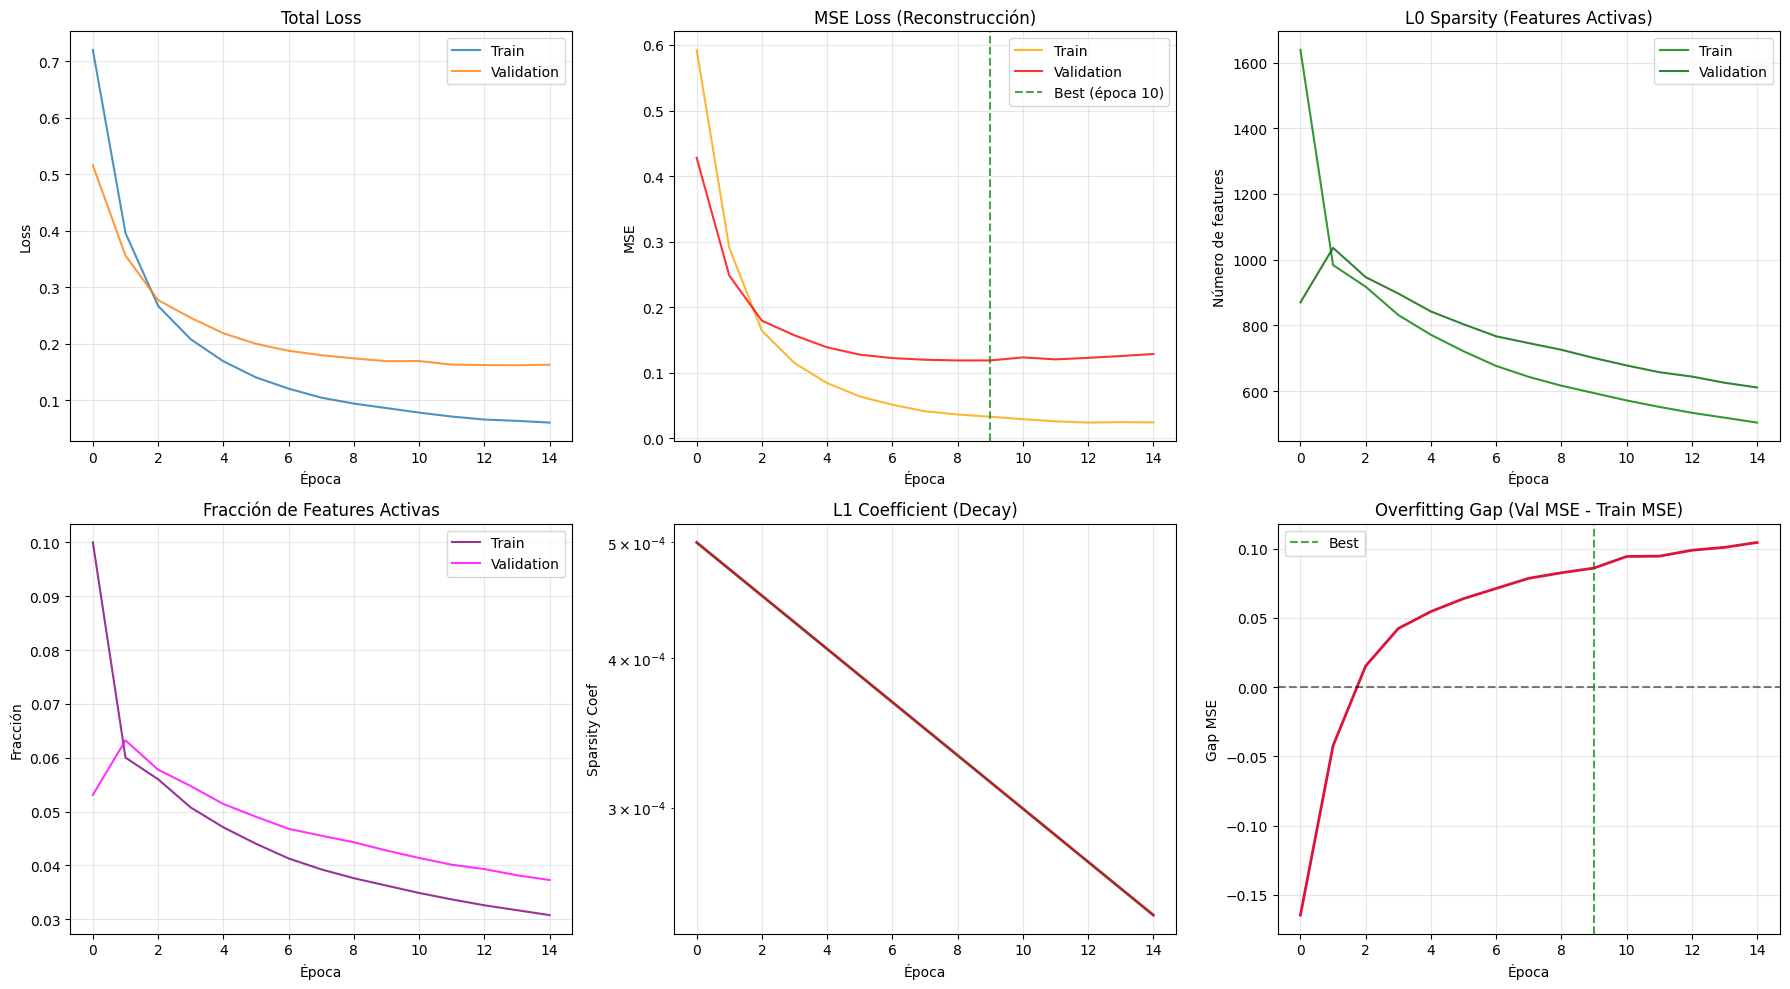

✓ Gráficas guardadas


In [39]:
# Gráficas de pérdidas (Train vs Validation) + L1 Decay
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Total loss
axes[0, 0].plot(history['train_total_loss'], label='Train', alpha=0.8)
axes[0, 0].plot(history['val_total_loss'], label='Validation', alpha=0.8)
axes[0, 0].set_title('Total Loss')
axes[0, 0].set_xlabel('Época')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# MSE loss
axes[0, 1].plot(history['train_mse_loss'], label='Train', color='orange', alpha=0.8)
axes[0, 1].plot(history['val_mse_loss'], label='Validation', color='red', alpha=0.8)
if CONFIG['early_stopping'] and best_epoch > 0:
    axes[0, 1].axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.7, label=f'Best (época {best_epoch})')
axes[0, 1].set_title('MSE Loss (Reconstrucción)')
axes[0, 1].set_xlabel('Época')
axes[0, 1].set_ylabel('MSE')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# L0 sparsity
axes[0, 2].plot(history['train_l0_sparsity'], label='Train', color='green', alpha=0.8)
axes[0, 2].plot(history['val_l0_sparsity'], label='Validation', color='darkgreen', alpha=0.8)
axes[0, 2].set_title('L0 Sparsity (Features Activas)')
axes[0, 2].set_xlabel('Época')
axes[0, 2].set_ylabel('Número de features')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Fraction active
axes[1, 0].plot(history['train_fraction_active'], label='Train', color='purple', alpha=0.8)
axes[1, 0].plot(history['val_fraction_active'], label='Validation', color='magenta', alpha=0.8)
axes[1, 0].set_title('Fracción de Features Activas')
axes[1, 0].set_xlabel('Época')
axes[1, 0].set_ylabel('Fracción')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Sparsity Coefficient (L1 Decay)
axes[1, 1].plot(history['sparsity_coef_history'], color='brown', linewidth=2)
axes[1, 1].set_title('L1 Coefficient (Decay)')
axes[1, 1].set_xlabel('Época')
axes[1, 1].set_ylabel('Sparsity Coef')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

# Train vs Val MSE Gap
mse_gap = [v - t for v, t in zip(history['val_mse_loss'], history['train_mse_loss'])]
axes[1, 2].plot(mse_gap, color='crimson', linewidth=2)
axes[1, 2].axhline(0, color='black', linestyle='--', alpha=0.5)
if CONFIG['early_stopping'] and best_epoch > 0:
    axes[1, 2].axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.7, label=f'Best')
axes[1, 2].set_title('Overfitting Gap (Val MSE - Train MSE)')
axes[1, 2].set_xlabel('Época')
axes[1, 2].set_ylabel('Gap MSE')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['plots_dir'], 'training_curves.png'), dpi=300)
plt.show()

print('✓ Gráficas guardadas')


## 9. Análisis de Activaciones

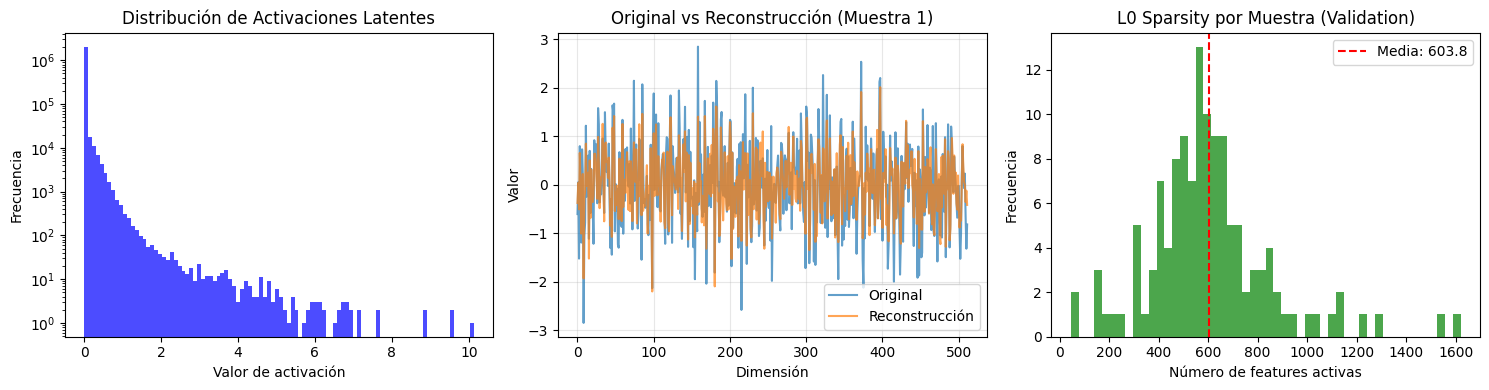


 Estadísticas de activaciones (Validation):
  L0 promedio: 603.8 / 16384
  Fracción activa: 3.685%
  MSE reconstrucción: 0.1222


In [40]:
# Obtener un batch de validación para análisis
model.eval()
sample_batch = next(iter(val_loader)).to(device)

with torch.no_grad():
    reconstruction, hidden = model(sample_batch)

# Convertir a numpy
hidden_np = hidden.cpu().numpy()
original_np = sample_batch.cpu().numpy()
recon_np = reconstruction.cpu().numpy()

# Visualizar distribución de activaciones
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histograma de activaciones latentes
axes[0].hist(hidden_np.flatten(), bins=100, alpha=0.7, color='blue')
axes[0].set_title('Distribución de Activaciones Latentes')
axes[0].set_xlabel('Valor de activación')
axes[0].set_ylabel('Frecuencia')
axes[0].set_yscale('log')

# Comparación original vs reconstrucción (primera muestra)
axes[1].plot(original_np[0], label='Original', alpha=0.7)
axes[1].plot(recon_np[0], label='Reconstrucción', alpha=0.7)
axes[1].set_title('Original vs Reconstrucción (Muestra 1)')
axes[1].set_xlabel('Dimensión')
axes[1].set_ylabel('Valor')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Sparsity por muestra
l0_per_sample = (hidden_np > 0).sum(axis=1)
axes[2].hist(l0_per_sample, bins=50, alpha=0.7, color='green')
axes[2].set_title('L0 Sparsity por Muestra (Validation)')
axes[2].set_xlabel('Número de features activas')
axes[2].set_ylabel('Frecuencia')
axes[2].axvline(l0_per_sample.mean(), color='red', linestyle='--', 
                label=f'Media: {l0_per_sample.mean():.1f}')
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['plots_dir'], 'activations_analysis.png'), dpi=300)
plt.show()

print(f'\n Estadísticas de activaciones (Validation):')
print(f'  L0 promedio: {l0_per_sample.mean():.1f} / {CONFIG["hidden_dim"]}')
print(f'  Fracción activa: {(hidden_np > 0).mean():.3%}')
print(f'  MSE reconstrucción: {F.mse_loss(reconstruction, sample_batch).item():.4f}')

## 10. Métricas de Calidad del Modelo

Evaluamos la calidad del SAE con múltiples métricas:
- **MSE**: Error de reconstrucción
- **Explained Variance**: % de varianza capturada
- **Cosine Similarity**: Similitud direccional entre original y reconstrucción
- **Dead Neurons**: Features que nunca se activan
- **Sparsity**: L0 promedio y distribución

In [41]:
def evaluate_model_quality(model, dataloader, device):
    """
    Evalúa la calidad del SAE con múltiples métricas
    """
    model.eval()
    
    all_originals = []
    all_reconstructions = []
    all_hiddens = []
    
    print('🔍 Evaluando calidad del modelo...\n')
    
    # Recolectar todas las predicciones
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluando'):
            x = batch.to(device)
            reconstruction, hidden = model(x)
            
            all_originals.append(x.cpu().numpy())
            all_reconstructions.append(reconstruction.cpu().numpy())
            all_hiddens.append(hidden.cpu().numpy())
    
    # Concatenar todos los batches
    originals = np.concatenate(all_originals, axis=0)
    reconstructions = np.concatenate(all_reconstructions, axis=0)
    hiddens = np.concatenate(all_hiddens, axis=0)
    
    metrics = {}
    
    # 1. MSE (Mean Squared Error)
    mse = np.mean((originals - reconstructions) ** 2)
    metrics['MSE'] = mse
    
    # 2. MAE (Mean Absolute Error)
    mae = np.mean(np.abs(originals - reconstructions))
    metrics['MAE'] = mae
    
    # 3. Explained Variance
    var_original = np.var(originals)
    var_residual = np.var(originals - reconstructions)
    explained_var = 1 - (var_residual / var_original)
    metrics['Explained_Variance'] = explained_var
    
    # 4. Cosine Similarity (promedio)
    # Normalizar vectores
    orig_norm = originals / (np.linalg.norm(originals, axis=1, keepdims=True) + 1e-8)
    recon_norm = reconstructions / (np.linalg.norm(reconstructions, axis=1, keepdims=True) + 1e-8)
    cosine_sim = np.sum(orig_norm * recon_norm, axis=1).mean()
    metrics['Cosine_Similarity'] = cosine_sim
    
    # 5. L0 Sparsity (features activas)
    l0_per_sample = (hiddens > 0).sum(axis=1)
    metrics['L0_mean'] = l0_per_sample.mean()
    metrics['L0_std'] = l0_per_sample.std()
    metrics['L0_min'] = l0_per_sample.min()
    metrics['L0_max'] = l0_per_sample.max()
    
    # 6. Fracción de features activas
    fraction_active = (hiddens > 0).mean()
    metrics['Fraction_Active'] = fraction_active
    
    # 7. Dead Neurons (nunca se activan)
    neuron_activations = (hiddens > 0).sum(axis=0)
    dead_neurons = (neuron_activations == 0).sum()
    metrics['Dead_Neurons'] = dead_neurons
    metrics['Dead_Neurons_Fraction'] = dead_neurons / hiddens.shape[1]
    
    # 8. L1 Norm (promedio de activaciones)
    l1_norm = np.abs(hiddens).mean()
    metrics['L1_Norm'] = l1_norm
    
    # 9. Max Activation
    max_activation = hiddens.max()
    metrics['Max_Activation'] = max_activation
    
    # 10. Reconstruction SNR (Signal-to-Noise Ratio)
    signal_power = np.mean(originals ** 2)
    noise_power = np.mean((originals - reconstructions) ** 2)
    snr = 10 * np.log10(signal_power / (noise_power + 1e-8))
    metrics['SNR_dB'] = snr
    
    return metrics, (originals, reconstructions, hiddens)

# Evaluar el modelo en el conjunto de VALIDACIÓN
print(' Evaluando en conjunto de VALIDACIÓN:')
metrics, (originals, reconstructions, hiddens) = evaluate_model_quality(model, val_loader, device)

 Evaluando en conjunto de VALIDACIÓN:
🔍 Evaluando calidad del modelo...



Evaluando: 100%|██████████| 10/10 [00:00<00:00, 33.29it/s]


In [42]:
# Imprimir métricas de calidad
print('\n' + '=' * 70)
print(' MÉTRICAS DE CALIDAD DEL MODELO')
print('=' * 70)

print('\n Calidad de Reconstrucción:')
print(f'  MSE: {metrics["MSE"]:.6f}')
print(f'  MAE: {metrics["MAE"]:.6f}')
print(f'  Explained Variance: {metrics["Explained_Variance"]:.2%}')
print(f'  Cosine Similarity: {metrics["Cosine_Similarity"]:.4f}')
print(f'  SNR: {metrics["SNR_dB"]:.2f} dB')

print('\n Sparsity:')
print(f'  L0 (media): {metrics["L0_mean"]:.1f} ± {metrics["L0_std"]:.1f}')
print(f'  L0 (rango): [{metrics["L0_min"]:.0f}, {metrics["L0_max"]:.0f}]')
print(f'  Fracción activa: {metrics["Fraction_Active"]:.3%}')
print(f'  L1 Norm: {metrics["L1_Norm"]:.4f}')
print(f'  Max Activation: {metrics["Max_Activation"]:.4f}')

print('\n Dead Neurons:')
print(f'  Número: {metrics["Dead_Neurons"]} / {CONFIG["hidden_dim"]}')
print(f'  Porcentaje: {metrics["Dead_Neurons_Fraction"]:.2%}')

print('\n' + '=' * 70)

# Interpretación automática
print('\n Interpretación:')
if metrics['Explained_Variance'] > 0.95:
    print('   Excelente reconstrucción (>95% varianza explicada)')
elif metrics['Explained_Variance'] > 0.85:
    print('  ✓ Buena reconstrucción (>85% varianza explicada)')
else:
    print('   Reconstrucción mejorable (<85% varianza explicada)')

if metrics['Fraction_Active'] < 0.05:
    print('   Muy buena sparsity (<5% features activas)')
elif metrics['Fraction_Active'] < 0.10:
    print('  ✓ Buena sparsity (<10% features activas)')
else:
    print('   Sparsity mejorable (>10% features activas)')

if metrics['Dead_Neurons_Fraction'] < 0.10:
    print('   Pocas neuronas muertas (<10%)')
elif metrics['Dead_Neurons_Fraction'] < 0.30:
    print('  ✓ Neuronas muertas aceptables (<30%)')
else:
    print('   Muchas neuronas muertas (>30%) - considera reducir hidden_dim')

print('=' * 70)


 MÉTRICAS DE CALIDAD DEL MODELO

 Calidad de Reconstrucción:
  MSE: 0.128548
  MAE: 0.277393
  Explained Variance: 84.84%
  Cosine Similarity: 0.9183
  SNR: 8.19 dB

 Sparsity:
  L0 (media): 613.3 ± 256.8
  L0 (rango): [45, 2417]
  Fracción activa: 3.744%
  L1 Norm: 0.0085
  Max Activation: 10.6645

 Dead Neurons:
  Número: 232 / 16384
  Porcentaje: 1.42%


 Interpretación:
   Reconstrucción mejorable (<85% varianza explicada)
   Muy buena sparsity (<5% features activas)
   Pocas neuronas muertas (<10%)


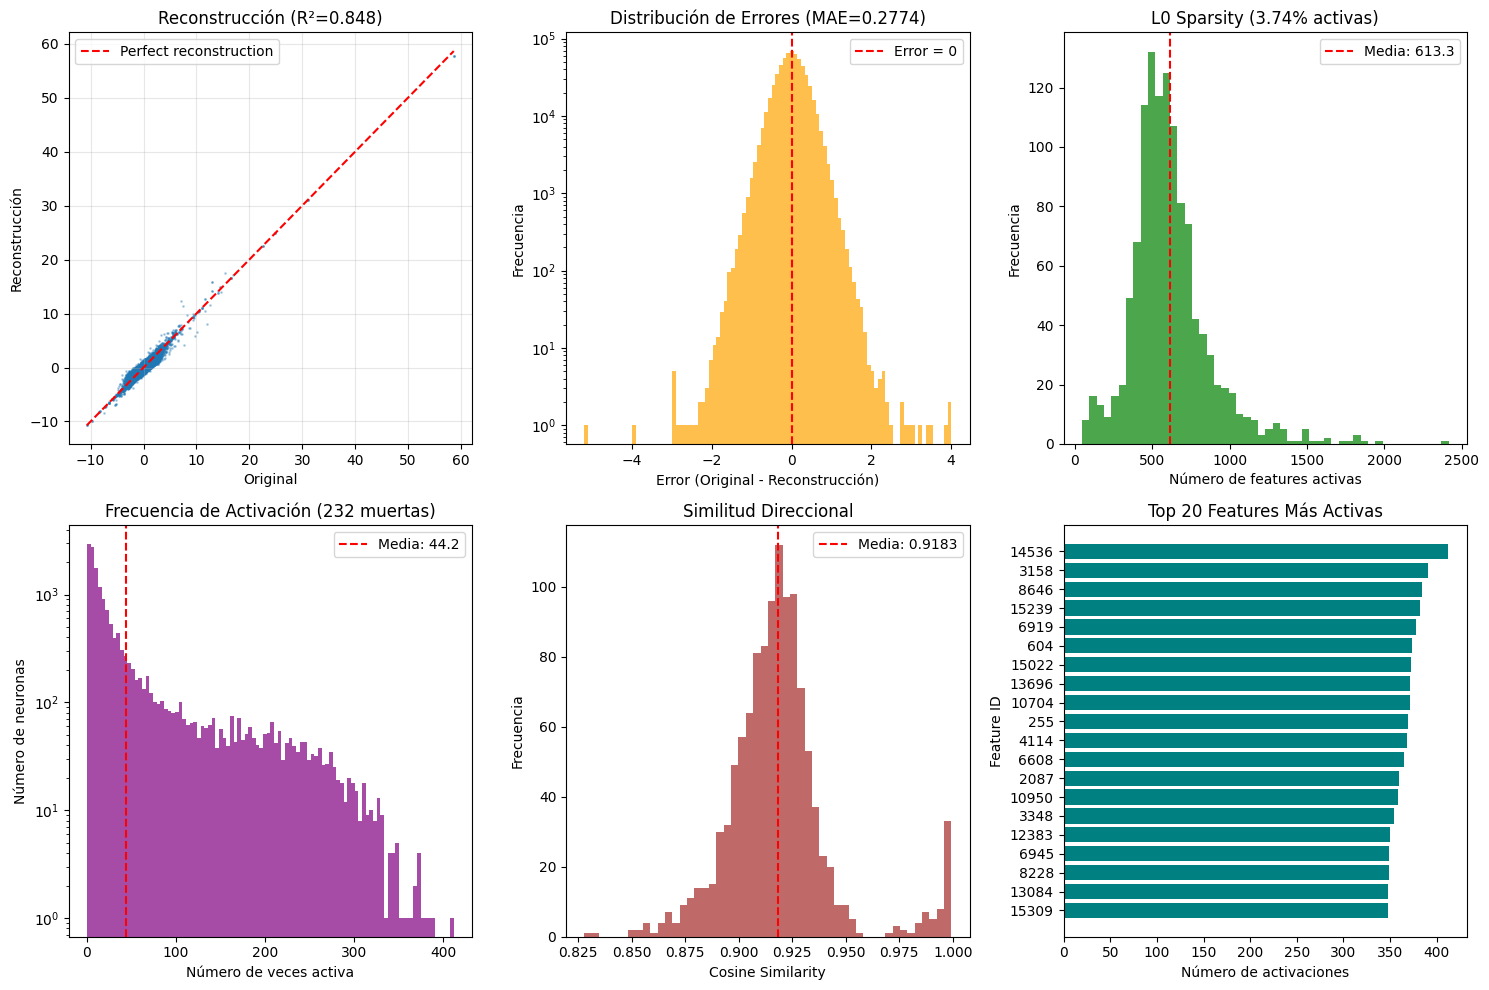

✓ Visualización de calidad guardada


In [43]:
# Visualización de métricas de calidad
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Scatter: Original vs Reconstrucción
sample_idx = np.random.choice(len(originals), 500, replace=False)
axes[0, 0].scatter(originals[sample_idx].flatten(), 
                   reconstructions[sample_idx].flatten(), 
                   alpha=0.3, s=1)
axes[0, 0].plot([originals.min(), originals.max()], 
                [originals.min(), originals.max()], 
                'r--', label='Perfect reconstruction')
axes[0, 0].set_xlabel('Original')
axes[0, 0].set_ylabel('Reconstrucción')
axes[0, 0].set_title(f'Reconstrucción (R²={metrics["Explained_Variance"]:.3f})')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Distribución de errores
errors = (originals - reconstructions).flatten()
axes[0, 1].hist(errors, bins=100, alpha=0.7, color='orange')
axes[0, 1].axvline(0, color='red', linestyle='--', label='Error = 0')
axes[0, 1].set_xlabel('Error (Original - Reconstrucción)')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_title(f'Distribución de Errores (MAE={metrics["MAE"]:.4f})')
axes[0, 1].legend()
axes[0, 1].set_yscale('log')

# 3. L0 Sparsity por muestra
l0_per_sample = (hiddens > 0).sum(axis=1)
axes[0, 2].hist(l0_per_sample, bins=50, alpha=0.7, color='green')
axes[0, 2].axvline(metrics['L0_mean'], color='red', linestyle='--', 
                   label=f'Media: {metrics["L0_mean"]:.1f}')
axes[0, 2].set_xlabel('Número de features activas')
axes[0, 2].set_ylabel('Frecuencia')
axes[0, 2].set_title(f'L0 Sparsity ({metrics["Fraction_Active"]:.2%} activas)')
axes[0, 2].legend()

# 4. Activaciones por neurona
neuron_activations = (hiddens > 0).sum(axis=0)
axes[1, 0].hist(neuron_activations, bins=100, alpha=0.7, color='purple')
axes[1, 0].axvline(neuron_activations.mean(), color='red', linestyle='--', 
                   label=f'Media: {neuron_activations.mean():.1f}')
axes[1, 0].set_xlabel('Número de veces activa')
axes[1, 0].set_ylabel('Número de neuronas')
axes[1, 0].set_title(f'Frecuencia de Activación ({metrics["Dead_Neurons"]} muertas)')
axes[1, 0].legend()
axes[1, 0].set_yscale('log')

# 5. Cosine Similarity por muestra
orig_norm = originals / (np.linalg.norm(originals, axis=1, keepdims=True) + 1e-8)
recon_norm = reconstructions / (np.linalg.norm(reconstructions, axis=1, keepdims=True) + 1e-8)
cosine_sims = np.sum(orig_norm * recon_norm, axis=1)
axes[1, 1].hist(cosine_sims, bins=50, alpha=0.7, color='brown')
axes[1, 1].axvline(metrics['Cosine_Similarity'], color='red', linestyle='--',
                   label=f'Media: {metrics["Cosine_Similarity"]:.4f}')
axes[1, 1].set_xlabel('Cosine Similarity')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].set_title('Similitud Direccional')
axes[1, 1].legend()

# 6. Top features más activas
top_n = 20
top_neurons = np.argsort(neuron_activations)[-top_n:][::-1]
top_activations = neuron_activations[top_neurons]
axes[1, 2].barh(range(top_n), top_activations, color='teal')
axes[1, 2].set_xlabel('Número de activaciones')
axes[1, 2].set_ylabel('Feature ID')
axes[1, 2].set_title(f'Top {top_n} Features Más Activas')
axes[1, 2].set_yticks(range(top_n))
axes[1, 2].set_yticklabels(top_neurons)
axes[1, 2].invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['plots_dir'], 'model_quality_metrics.png'), dpi=300)
plt.show()

print('✓ Visualización de calidad guardada')

## 11. Resumen Final

In [31]:
print('\n' + '=' * 70)
print(' RESUMEN FINAL DEL ENTRENAMIENTO')
print('=' * 70)
print(f'\n Arquitectura:')
print(f'  Input: {CONFIG["input_dim"]}')
print(f'  Hidden: {CONFIG["hidden_dim"]} (expansión {CONFIG["hidden_dim"]/CONFIG["input_dim"]:.1f}x)')
print(f'  Parámetros: {num_params:,}')

print(f'\n Datos:')
print(f'  Train: {len(train_dataset)} muestras')
print(f'  Validation: {len(val_dataset)} muestras')

print(f'\n Métricas finales (última época):')
print(f'  Train Loss: {history["train_total_loss"][-1]:.4f} | Val Loss: {history["val_total_loss"][-1]:.4f}')
print(f'  Train MSE: {history["train_mse_loss"][-1]:.4f} | Val MSE: {history["val_mse_loss"][-1]:.4f}')
print(f'  Train L0: {history["train_l0_sparsity"][-1]:.1f} | Val L0: {history["val_l0_sparsity"][-1]:.1f}')
print(f'  Train Frac: {history["train_fraction_active"][-1]:.3%} | Val Frac: {history["val_fraction_active"][-1]:.3%}')

print(f'\n Archivos guardados:')
print(f'  Modelo: {checkpoint_path}')
print(f'  Gráficas: {CONFIG["plots_dir"]}/training_curves.png')
print(f'  Análisis: {CONFIG["plots_dir"]}/activations_analysis.png')
print(f'  Métricas: {CONFIG["plots_dir"]}/model_quality_metrics.png')

print('\n' + '=' * 70)
print(' Entrenamiento completado exitosamente!')
print('=' * 70)


 RESUMEN FINAL DEL ENTRENAMIENTO

 Arquitectura:
  Input: 512
  Hidden: 16384 (expansión 32.0x)
  Parámetros: 16,794,112

 Datos:
  Train: 4720 muestras
  Validation: 1180 muestras

 Métricas finales (última época):
  Train Loss: 0.0685 | Val Loss: 0.2324
  Train MSE: 0.0295 | Val MSE: 0.2011
  Train L0: 185.0 | Val L0: 236.5
  Train Frac: 1.129% | Val Frac: 1.444%

 Archivos guardados:
  Modelo: /saved_model\sae_othello_final.pt
  Gráficas: /plots/training_curves.png
  Análisis: /plots/activations_analysis.png
  Métricas: /plots/model_quality_metrics.png

 Entrenamiento completado exitosamente!
